In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab_dataset/Student_performance.csv")

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,student_performance
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.300,Excellent
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.700,Poor
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.000,Excellent
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.900,Good
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.000,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate,69.500,Good
629996,629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate,78.900,Excellent
629997,629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate,19.599,Poor
629998,629998,20,male,b.com,1.54,75.1,yes,8.2,average,group study,high,moderate,59.100,Average


In [6]:
df_model = df.copy()

In [7]:
# df_model.columns = df_model.columns.str.strip()
# for col in df_model.select_dtypes(include='object').columns:
#     df_model[col] = df_model[col].str.strip()

# Drop ID & Leakage
if 'id' in df_model.columns: df_model.drop(columns=['id'], inplace=True)
if 'exam_score' in df_model.columns: df_model.drop(columns=['exam_score'], inplace=True)

In [8]:
df_model

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,student_performance
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,Excellent
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,Poor
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,Excellent
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,Good
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...
629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate,Good
629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate,Excellent
629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate,Poor
629998,20,male,b.com,1.54,75.1,yes,8.2,average,group study,high,moderate,Average


In [9]:
df_model.isnull().sum()

,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0
facility_rating,0


In [10]:
df_model.shape

(630000, 12)

In [11]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  630000 non-null  int64  
 1   gender               630000 non-null  object 
 2   course               630000 non-null  object 
 3   study_hours          630000 non-null  float64
 4   class_attendance     630000 non-null  float64
 5   internet_access      630000 non-null  object 
 6   sleep_hours          630000 non-null  float64
 7   sleep_quality        630000 non-null  object 
 8   study_method         630000 non-null  object 
 9   facility_rating      630000 non-null  object 
 10  exam_difficulty      630000 non-null  object 
 11  student_performance  630000 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 57.7+ MB


In [12]:
df_model.describe()

,age,study_hours,class_attendance,sleep_hours
count,630000.000000,630000.000000,630000.000000,630000.000000
mean,20.545821,4.002337,71.987261,7.072758
std,2.260238,2.359880,17.430098,1.744811
min,17.000000,0.080000,40.600000,4.100000
25%,19.000000,1.970000,57.000000,5.600000
50%,21.000000,4.000000,72.600000,7.100000
75%,23.000000,6.050000,87.200000,8.600000
max,24.000000,7.910000,99.400000,9.900000


In [13]:
df_model.duplicated().sum()

np.int64(0)

In [14]:
df_model['age'].sort_values(ascending=False).unique()[0:10]

array([24, 23, 22, 21, 20, 19, 18, 17])

In [15]:
df_model['study_hours'].sort_values(ascending=False).unique()[0:10]

array([7.91, 7.9 , 7.89, 7.88, 7.87, 7.86, 7.85, 7.84, 7.83, 7.82])

In [16]:
df_model['gender'].value_counts()

,count
gender,
other,211097
male,210593
female,208310


In [17]:
df_model['course'].value_counts()

,count
course,
b.tech,131236
b.sc,111554
b.com,110932
bca,88721
bba,75644
ba,61989
diploma,49924


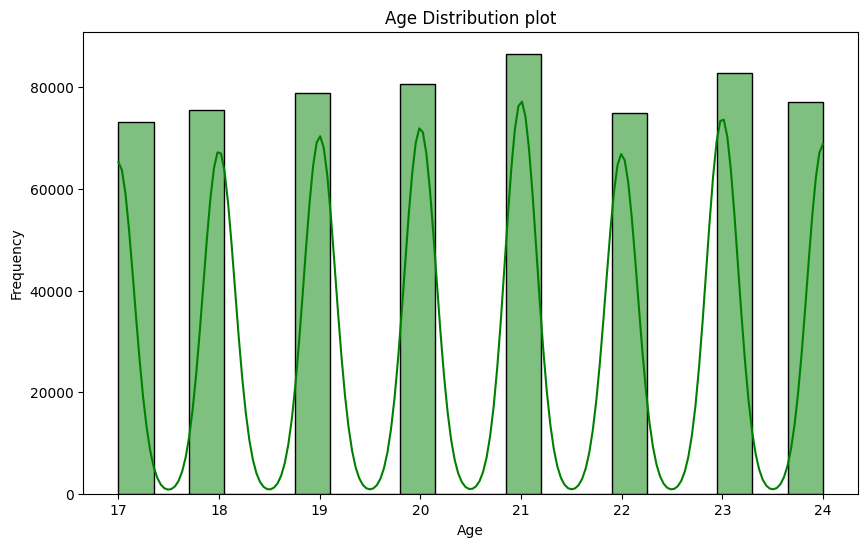

In [32]:
plt.figure(figsize=(10,6))
sns.histplot(df['age'].dropna(), bins=20, color='green',kde=True)
plt.title("Age Distribution plot")
plt.xlabel('Age')
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='gender', ylabel='count'>

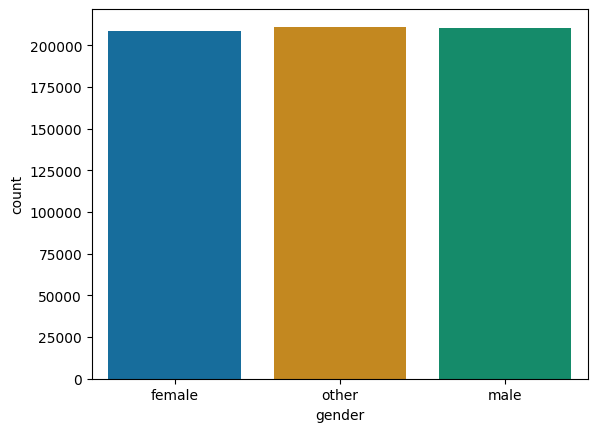

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='gender',data=df_model, palette='colorblind' )

<Axes: xlabel='course', ylabel='count'>

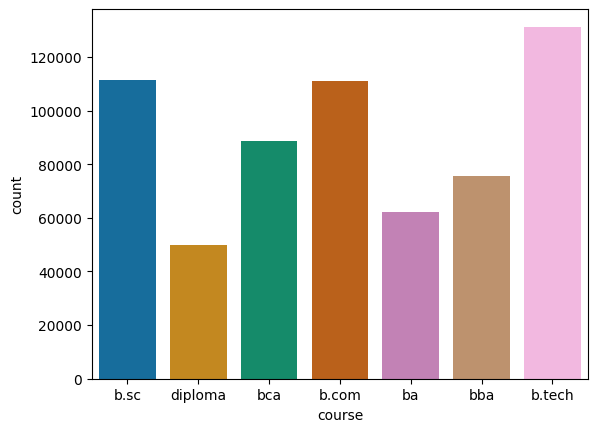

In [19]:
sns.countplot(x='course',data=df_model, palette='colorblind' )

<Axes: xlabel='internet_access', ylabel='count'>

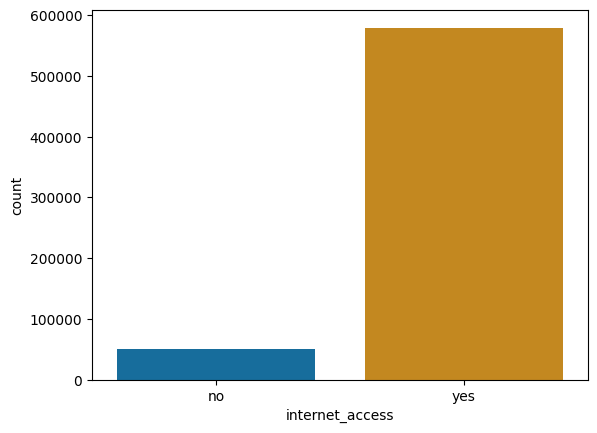

In [20]:
sns.countplot(x='internet_access',data=df_model, palette='colorblind' )

<Axes: ylabel='sleep_quality'>

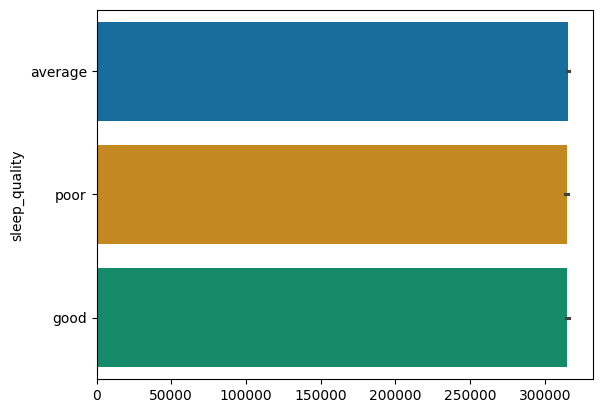

In [27]:
sns.barplot(df_model['sleep_quality'],palette='colorblind')

<Axes: xlabel='class_attendance', ylabel='Count'>

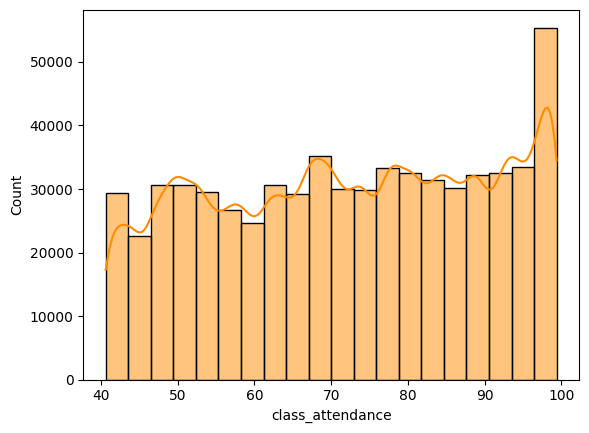

In [29]:

sns.histplot(df_model['class_attendance'],bins=20, kde=True,color='darkorange')

In [30]:
df_model['facility_rating'].unique()

array(['low', 'medium', 'high'], dtype=object)

<Axes: xlabel='facility_rating', ylabel='count'>

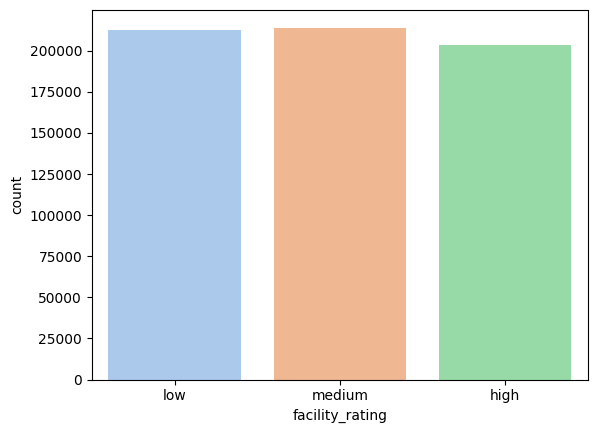

In [31]:
sns.countplot(x='facility_rating', data=df_model, palette='pastel')

<Axes: xlabel='study_method', ylabel='count'>

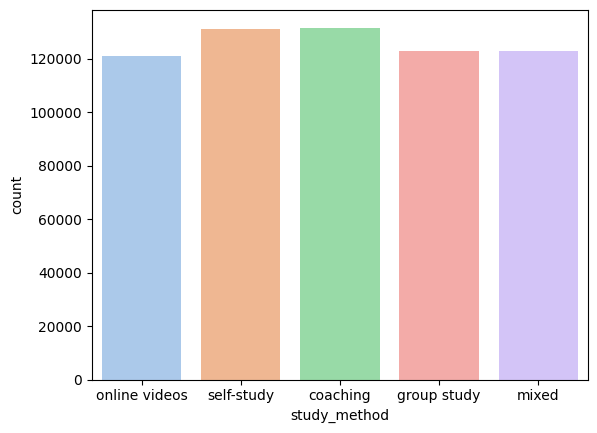

In [33]:
sns.countplot(x='study_method', data=df_model, palette='pastel')

<Axes: xlabel='study_hours', ylabel='Count'>

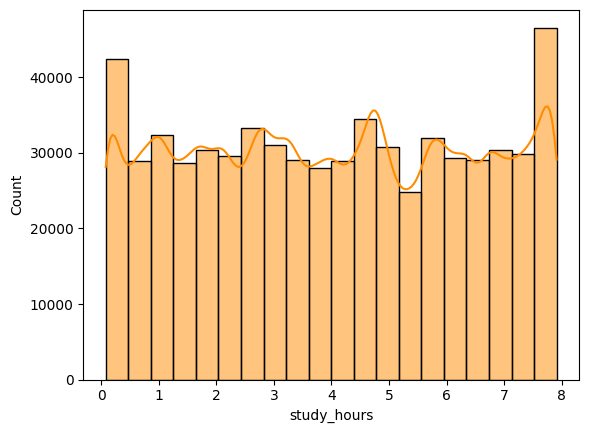

In [35]:

sns.histplot(df_model['study_hours'],bins=20, kde=True,color='darkorange')

In [57]:
df_model.columns

Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'student_performance'],
      dtype='object')

In [60]:
df_model.shape

(630000, 12)

<Axes: >

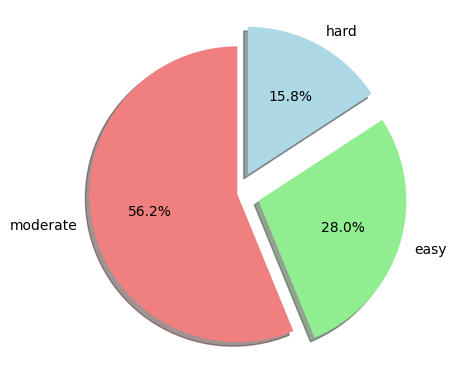

In [41]:
df_model['exam_difficulty'].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,colors=["lightcoral",'lightgreen', 'lightblue'],explode=(0,0.15,0.15),shadow=True,ylabel="")

<Axes: xlabel='age', ylabel='study_hours'>

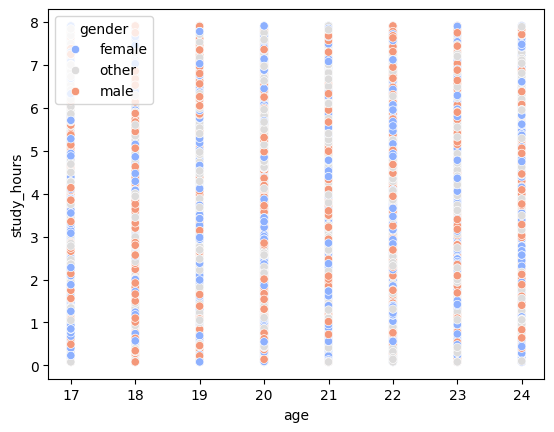

In [56]:
sns.scatterplot(x='age',y='study_hours',data=df_model, hue='gender',palette='coolwarm')

In [55]:
# sns.pairplot(df_model[num_col + ['student_performance']], hue='student_performance', palette='husl')

In [64]:
corr=df_model.corr(numeric_only=True)

<Axes: >

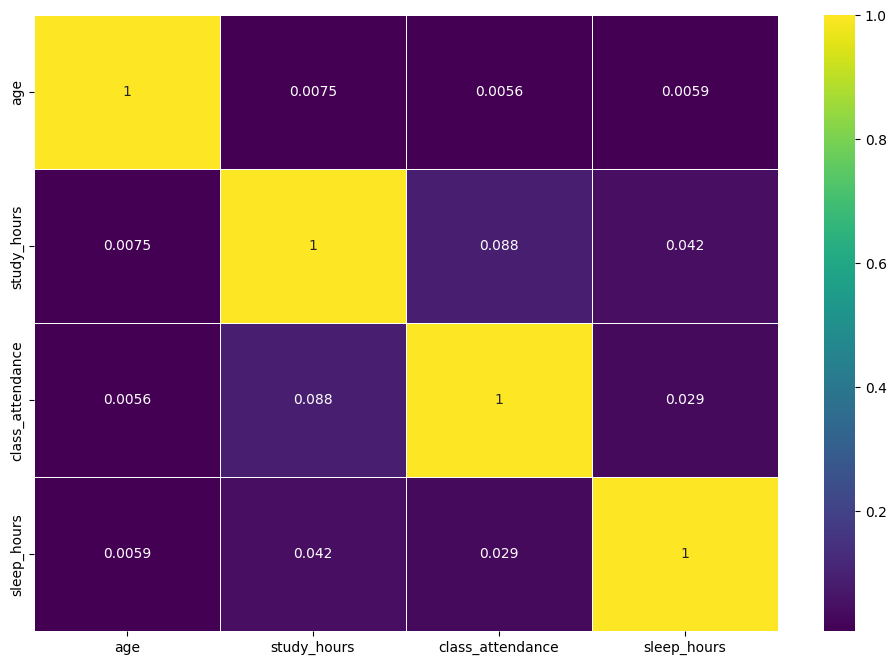

In [66]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='viridis', linewidths=0.5)

In [67]:
# Target (IMPORTANT FIX)
df_model['student_performance'] = df_model['student_performance'].map({
    'Poor': 0,
    'Average': 1,
    'Good': 1,
    'Excellent': 2
})

# Ordinal features
df_model['sleep_quality'] = df_model['sleep_quality'].map({'poor': 0, 'average': 1, 'good': 2})
df_model['facility_rating'] = df_model['facility_rating'].map({'low': 0, 'medium': 1, 'high': 2})
df_model['exam_difficulty'] = df_model['exam_difficulty'].map({'easy': 0, 'moderate': 1, 'hard': 2})

# Binary
df_model['internet_access'] = df_model['internet_access'].map({'yes': 1, 'no': 0})

# OneHot (IMPORTANT)
df_model = pd.get_dummies(df_model, columns=['gender', 'course', 'study_method'])

In [68]:
df_model.head()

,age,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,facility_rating,exam_difficulty,student_performance,gender_female,...,course_b.tech,course_ba,course_bba,course_bca,course_diploma,study_method_coaching,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study
0,21,7.91,98.8,0,4.9,1,0,0,2,True,...,False,False,False,False,False,False,False,False,True,False
1,18,4.95,94.8,1,4.7,0,1,1,0,False,...,False,False,False,False,True,False,False,False,False,True
2,20,4.68,92.6,1,5.8,0,2,1,2,True,...,False,False,False,False,False,True,False,False,False,False
3,19,2.00,49.5,1,8.3,1,2,1,1,False,...,False,False,False,False,False,False,True,False,False,False
4,23,7.65,86.9,1,9.6,2,2,0,2,False,...,False,False,False,True,False,False,False,False,False,True


In [69]:
df_model['student_performance'].value_counts(normalize=True)

,proportion
student_performance,
1,0.501362
0,0.250538
2,0.248100


In [70]:
# # Creating  Features
# df_model['study_efficiency'] = df_model['study_hours'] * (df_model['class_attendance'] / 100)
# df_model['consistency'] = df_model['study_hours'] * df_model['sleep_hours']
# df_model['wellness_index'] = df_model['sleep_quality'] * df_model['sleep_hours']
# df_model['risk_factor'] = df_model['exam_difficulty'] / (df_model['study_hours'] + 0.1)

# Removing Dependency
# cols_to_remove = ['study_hours', 'class_attendance', 'sleep_hours']
# df_model.drop(columns=cols_to_remove, inplace=True)

In [71]:
# Target ko alag kiya (Text format mein hi hai)
y = df_model['student_performance']
X = df_model.drop(columns=['student_performance'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [72]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Mean of Scaled Data (Approx 0): {np.mean(X_train_scaled):.4f}")
print(f"Std Dev of Scaled Data (Approx 1): {np.std(X_train_scaled):.4f}")

Mean of Scaled Data (Approx 0): 0.0000
Std Dev of Scaled Data (Approx 1): 1.0000


In [73]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

model = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42)


model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# 4. Accuracy Check
acc = accuracy_score(y_test, y_pred)

print("\n" + "="*50)
print(f"FINAL MODEL ACCURACY: {acc*100:.2f}%")
print("="*50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


FINAL MODEL ACCURACY: 76.45%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76     31568
           1       0.75      0.80      0.77     63171
           2       0.78      0.73      0.75     31261

    accuracy                           0.76    126000
   macro avg       0.77      0.75      0.76    126000
weighted avg       0.77      0.76      0.76    126000



In [74]:
from xgboost import XGBClassifier

model2 = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_lambda=1,
    reg_alpha=0.1
)
model2.fit(X_train_scaled, y_train)

y_pred = model2.predict(X_test_scaled)

# 4. Accuracy Check
acc = accuracy_score(y_test, y_pred)

print("\n" + "="*50)
print(f"FINAL MODEL ACCURACY: {acc*100:.2f}%")
print("="*50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


FINAL MODEL ACCURACY: 76.47%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76     31568
           1       0.75      0.80      0.77     63171
           2       0.78      0.72      0.75     31261

    accuracy                           0.76    126000
   macro avg       0.77      0.75      0.76    126000
weighted avg       0.77      0.76      0.76    126000



In [75]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Initialize XGBClassifier (using the existing model from a1qE5_gyW5fh as a base)
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3, # Using 3-fold cross-validation for speed, can be increased for more robust results
    verbose=1,
    n_jobs=-1 # Use all available cores
)

print("Starting GridSearchCV for XGBoost...")
# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

print("GridSearchCV completed.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest Parameters found: {best_params}")
print(f"Best Cross-validation Accuracy: {best_score*100:.2f}%")

# Evaluate the best model on the test set
best_xgb_model = grid_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test_scaled)

acc_tuned = accuracy_score(y_test, y_pred_tuned)

print("\n" + "="*50)
print(f"TUNED XGBOOST MODEL ACCURACY on Test Set: {acc_tuned*100:.2f}%")
print("="*50)

print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred_tuned))

Starting GridSearchCV for XGBoost...
Fitting 3 folds for each of 243 candidates, totalling 729 fits


KeyboardInterrupt: 

In [ ]:
import joblib

joblib.dump(model, "student.pkl")

['student.pkl']